In [269]:
import numpy as np
import pandas as pd 
import statistics as sts 
import joblib
import seaborn as sns 
from matplotlib import pyplot as plt 
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,PowerTransformer,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.metrics import f1_score,classification_report,confusion_matrix,precision_score,recall_score

In [270]:
df=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred15\Loan Approval Prediction.csv",encoding_errors='ignore')

In [271]:
df.sample(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
276,LP001903,Male,Yes,0,Graduate,No,3993,3274.0,207.0,360.0,1.0,Semiurban,Y
69,LP001241,Female,No,0,Graduate,No,4300,0.0,136.0,360.0,0.0,Semiurban,N
186,LP001641,Male,Yes,1,Graduate,Yes,2178,0.0,66.0,300.0,0.0,Rural,N
310,LP002002,Female,No,0,Graduate,No,2917,0.0,84.0,360.0,1.0,Semiurban,Y
590,LP002928,Male,Yes,0,Graduate,No,3000,3416.0,56.0,180.0,1.0,Semiurban,Y
575,LP002868,Male,Yes,2,Graduate,No,3159,461.0,108.0,84.0,1.0,Urban,Y
235,LP001784,Male,Yes,1,Graduate,No,5500,1260.0,170.0,360.0,1.0,Rural,Y
476,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,Y
368,LP002190,Male,Yes,1,Graduate,No,6325,0.0,175.0,360.0,1.0,Semiurban,Y
122,LP001431,Female,No,0,Graduate,No,2137,8980.0,137.0,360.0,0.0,Semiurban,Y


In [272]:
df.shape

(614, 13)

In [273]:
df.ndim

2

In [274]:
df.size

7982

In [275]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [276]:
df[df.duplicated()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [277]:
df1=df.copy()

In [278]:
df1.sample(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
476,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,Y
204,LP001691,Male,Yes,2,Not Graduate,No,3917,0.0,124.0,360.0,1.0,Semiurban,Y


In [279]:
df1.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [280]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [281]:
df1.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [282]:
df1.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [283]:
df1.sample(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
492,LP002571,Male,No,0,Not Graduate,No,3691,0.0,110.0,360.0,1.0,Rural,Y
368,LP002190,Male,Yes,1,Graduate,No,6325,0.0,175.0,360.0,1.0,Semiurban,Y
165,LP001574,Male,Yes,0,Graduate,No,3707,3166.0,182.0,NaN,1.0,Rural,Y
309,LP001998,Male,Yes,2,Not Graduate,No,7667,0.0,185.0,360.0,NaN,Rural,Y
384,LP002236,Male,Yes,2,Graduate,No,4566,0.0,100.0,360.0,1.0,Urban,N


In [284]:
df1['Gender']=df1['Gender'].fillna(sts.mode(df1['Gender']))

In [285]:
imputer = SimpleImputer(strategy='most_frequent')
df1[['Dependents']]=imputer.fit_transform(df1[['Dependents']])

In [286]:
imputer = SimpleImputer(strategy='most_frequent')
df1[['Married']]=imputer.fit_transform(df1[['Married']])

In [287]:
imputer = SimpleImputer(strategy='most_frequent')
df1[['Self_Employed']]=imputer.fit_transform(df1[['Self_Employed']])

In [288]:
knnim=KNNImputer(n_neighbors=10,weights='distance')
df1[['LoanAmount']]=knnim.fit_transform(df1[['LoanAmount']])

In [289]:
knnim=KNNImputer(n_neighbors=10,weights='distance')
df1[['Loan_Amount_Term','Credit_History']]=knnim.fit_transform(df1[['Loan_Amount_Term','Credit_History']])

In [290]:
df1.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.000000,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.000000,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.000000,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.000000,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.000000,360.0,1.0,Semiurban,N


In [291]:
df1.tail(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
604,LP002959,Female,Yes,1,Graduate,No,12000,0.0,496.000000,360.0,1.0,Semiurban,Y
605,LP002960,Male,Yes,0,Not Graduate,No,2400,3800.0,146.412162,180.0,1.0,Urban,N
606,LP002961,Male,Yes,1,Graduate,No,3400,2500.0,173.000000,360.0,1.0,Semiurban,Y
607,LP002964,Male,Yes,2,Not Graduate,No,3987,1411.0,157.000000,360.0,1.0,Rural,Y
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.000000,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.000000,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.000000,360.0,0.0,Semiurban,N


In [292]:
df1.groupby('Gender')['Married'].agg(
    max_mmarried= "max",
    min_married= 'min',
    total_married='count',
    size='size',
    first='first',
    last='last'
)

,max_mmarried,min_married,total_married,size,first,last
Gender,,,,,,
Female,Yes,No,112,112,No,No
Male,Yes,No,502,502,No,Yes


In [293]:
#encoding values

label=LabelEncoder()
df1['Gender_encoded']=label.fit_transform(df1['Gender'])

In [294]:
oridinal=OrdinalEncoder(dtype=int)
df1[['Self_Employed_encoded','Property_Area_Encoded']]=oridinal.fit_transform(df1[['Self_Employed','Property_Area']])

In [295]:
label=LabelEncoder()
df1['Education_encoded']=label.fit_transform(df1['Education'])

In [296]:
label=LabelEncoder()
df1['Loan_Status']=label.fit_transform(df1['Loan_Status'])

In [297]:
df2=df1.copy()

In [298]:
numeric_col=df2.select_dtypes(include='number',exclude='object').columns
print(numeric_col)
cata_col=df2.select_dtypes(include='object',exclude='number').columns
print(cata_col)

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_encoded',
       'Self_Employed_encoded', 'Property_Area_Encoded', 'Education_encoded'],
      dtype='object')
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area'],
      dtype='object')


In [299]:
df2.drop(columns=['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education'],axis=1,inplace=True)

In [300]:
df2.columns

Index(['Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Gender_encoded', 'Self_Employed_encoded', 'Property_Area_Encoded',
       'Education_encoded'],
      dtype='object')

In [301]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Self_Employed          614 non-null    object 
 1   ApplicantIncome        614 non-null    int64  
 2   CoapplicantIncome      614 non-null    float64
 3   LoanAmount             614 non-null    float64
 4   Loan_Amount_Term       614 non-null    float64
 5   Credit_History         614 non-null    float64
 6   Property_Area          614 non-null    object 
 7   Loan_Status            614 non-null    int64  
 8   Gender_encoded         614 non-null    int64  
 9   Self_Employed_encoded  614 non-null    int64  
 10  Property_Area_Encoded  614 non-null    int64  
 11  Education_encoded      614 non-null    int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 57.7+ KB


In [302]:
df2.sample(10)

,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_encoded,Self_Employed_encoded,Property_Area_Encoded,Education_encoded
192,No,6033,0.0,160.0,360.0,1.0,Urban,0,1,0,2,1
563,Yes,5800,0.0,132.0,360.0,1.0,Semiurban,1,1,1,1,1
155,No,39999,0.0,600.0,180.0,0.0,Semiurban,1,1,0,1,0
187,No,2383,2138.0,58.0,360.0,0.9,Rural,1,1,0,0,0
370,Yes,15759,0.0,55.0,360.0,1.0,Semiurban,1,0,1,1,0
440,No,3660,5064.0,187.0,360.0,1.0,Semiurban,1,1,0,1,0
549,No,2785,2016.0,110.0,360.0,1.0,Rural,1,1,0,0,0
16,No,3596,0.0,100.0,240.0,1.0,Urban,1,1,0,2,1
335,Yes,5503,4490.0,70.0,360.0,1.0,Semiurban,1,1,1,1,0
216,No,150,1800.0,135.0,360.0,1.0,Rural,0,1,0,0,0


In [303]:
df2[['Loan_Amount_Term','CoapplicantIncome','LoanAmount','Credit_History']]

,Loan_Amount_Term,CoapplicantIncome,LoanAmount,Credit_History
0,360.0,0.0,146.412162,1.0
1,360.0,1508.0,128.000000,1.0
2,360.0,0.0,66.000000,1.0
3,360.0,2358.0,120.000000,1.0
4,360.0,0.0,141.000000,1.0
...,...,...,...,...
609,360.0,0.0,71.000000,1.0
610,180.0,0.0,40.000000,1.0
611,360.0,240.0,253.000000,1.0
612,360.0,0.0,187.000000,1.0


In [304]:
df2['Loan_Amount_Term']=pd.to_numeric(df1['Loan_Amount_Term'],errors='coerce').astype(int)

In [305]:
df2['CoapplicantIncome']=pd.to_numeric(df1['CoapplicantIncome'],errors='coerce').astype(int)

In [306]:
df2['Credit_History']=pd.to_numeric(df1['Credit_History'],errors='coerce').astype(int)

In [307]:
df2.sample(10)

,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_encoded,Self_Employed_encoded,Property_Area_Encoded,Education_encoded
314,No,2473,1843,159.0,360,1,Rural,0,1,0,0,0
516,No,2031,1632,113.0,480,1,Semiurban,1,0,0,1,0
340,No,2647,1587,173.0,360,1,Rural,0,1,0,0,1
61,No,3029,0,99.0,360,1,Urban,1,1,0,2,0
231,No,3716,0,42.0,180,1,Rural,1,1,0,0,0
379,No,5391,0,130.0,360,1,Urban,1,1,0,2,0
403,No,1963,0,53.0,360,1,Semiurban,1,0,0,1,1
106,No,11417,1126,225.0,360,1,Urban,1,1,0,2,0
377,No,4310,0,130.0,360,0,Semiurban,1,1,0,1,0
59,No,3357,2859,144.0,360,1,Urban,1,1,0,2,1


In [308]:
df2.columns

Index(['Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Gender_encoded', 'Self_Employed_encoded', 'Property_Area_Encoded',
       'Education_encoded'],
      dtype='object')

In [309]:
df2.sample(10)

,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_encoded,Self_Employed_encoded,Property_Area_Encoded,Education_encoded
245,Yes,6050,4333,120.0,180,1,Urban,0,1,1,2,0
569,No,3166,2064,104.0,360,0,Urban,0,1,0,2,0
498,Yes,2895,0,95.0,360,1,Semiurban,1,1,1,1,0
129,No,6080,2569,182.0,360,0,Rural,0,1,0,0,0
354,No,2423,505,130.0,360,1,Semiurban,1,0,0,1,0
329,No,2500,0,67.0,360,1,Urban,1,0,0,2,0
577,No,3229,2739,110.0,360,1,Urban,1,1,0,2,0
302,No,5000,0,132.0,360,1,Rural,1,0,0,0,0
424,No,14880,0,96.0,360,1,Semiurban,1,1,0,1,0
121,No,4166,0,44.0,360,1,Semiurban,1,0,0,1,0


In [310]:
x=df2[[ 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History',
       'Gender_encoded', 'Education_encoded', 'Self_Employed_encoded',
       'Property_Area_Encoded']]
y=df2['Loan_Status'].squeeze()

In [311]:
from sklearn.feature_selection import SelectKBest,f_classif

In [312]:
columnsFind=SelectKBest(score_func=f_classif,k=9)
columnsFind.fit(x,y)


,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...0020A2BEB3D80>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",9


In [313]:
columnsFinds=x.columns[columnsFind.get_support()]
columnsFinds

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_encoded',
       'Education_encoded', 'Self_Employed_encoded', 'Property_Area_Encoded'],
      dtype='object')

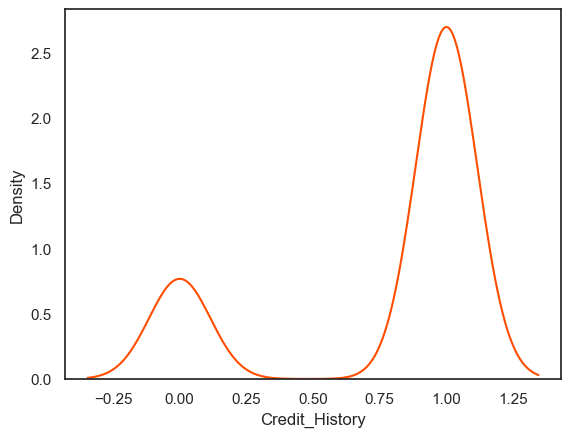

In [314]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['Credit_History'])
plt.show()

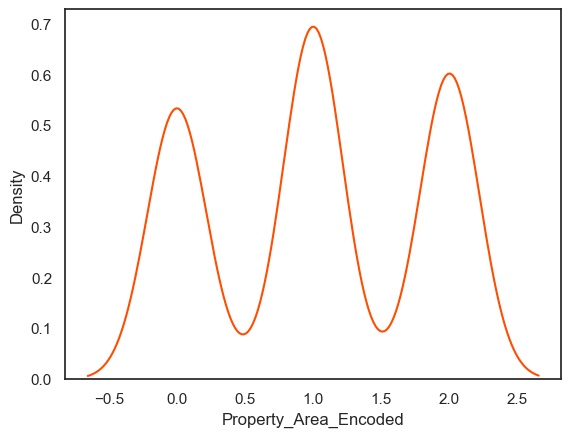

In [315]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['Property_Area_Encoded'])
plt.show()

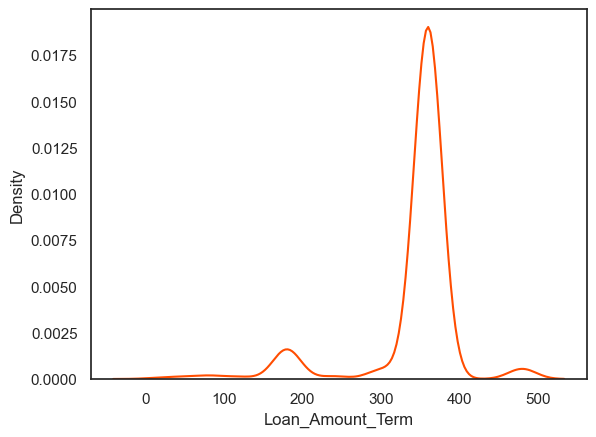

In [316]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['Loan_Amount_Term'])
plt.show()

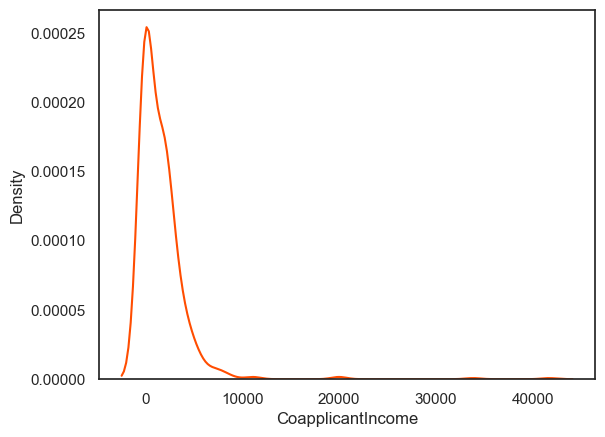

In [317]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['CoapplicantIncome'])
plt.show()

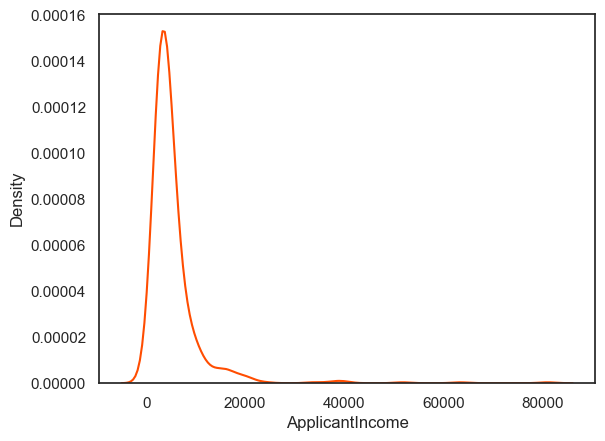

In [318]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['ApplicantIncome'])
plt.show()

In [319]:
spearman=df2.corr(method='spearman').round(2)
spearman

ValueError: could not convert string to float: 'No'

In [ ]:
pearson=df2.corr(method='pearson').round(2)
pearson

,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_encoded,Education_encoded,Self_Employed_encoded,Property_Area_Encoded
Self_Employed,1.00,0.13,-0.02,0.12,-0.03,0.00,-0.03,-0.00,-0.00,-0.01,1.00,-0.03
ApplicantIncome,0.13,1.00,-0.12,0.57,-0.05,0.01,-0.01,-0.00,0.06,-0.14,0.13,-0.01
CoapplicantIncome,-0.02,-0.12,1.00,0.19,-0.06,-0.06,0.01,-0.06,0.08,-0.06,-0.02,0.01
LoanAmount,0.12,0.57,0.19,1.00,0.04,-0.04,-0.04,-0.04,0.11,-0.17,0.12,-0.04
Loan_Amount_Term,-0.03,-0.05,-0.06,0.04,1.00,-0.03,-0.08,-0.02,-0.07,-0.08,-0.03,-0.08
Credit_History,0.00,0.01,-0.06,-0.04,-0.03,1.00,-0.01,0.44,0.03,-0.08,0.00,-0.01
Property_Area,-0.03,-0.01,0.01,-0.04,-0.08,-0.01,1.00,0.03,-0.03,-0.07,-0.03,1.00
Loan_Status,-0.00,-0.00,-0.06,-0.04,-0.02,0.44,0.03,1.00,0.02,-0.09,-0.00,0.03
Gender_encoded,-0.00,0.06,0.08,0.11,-0.07,0.03,-0.03,0.02,1.00,0.05,-0.00,-0.03
Education_encoded,-0.01,-0.14,-0.06,-0.17,-0.08,-0.08,-0.07,-0.09,0.05,1.00,-0.01,-0.07


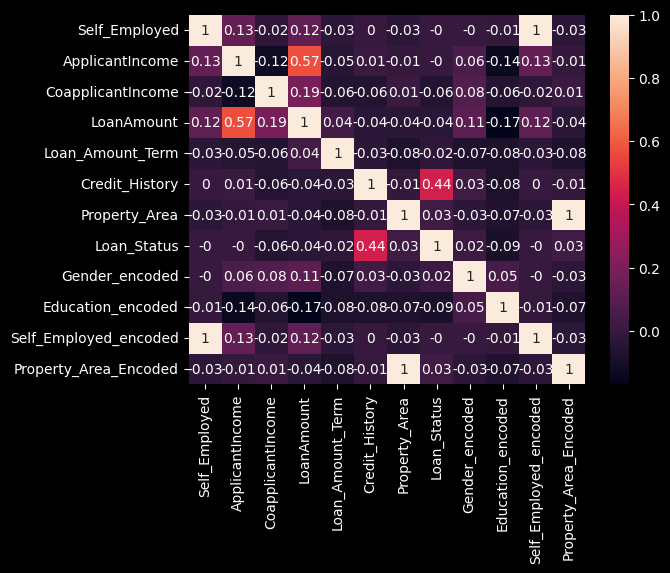

In [ ]:
sns.heatmap(pearson,annot=True)
plt.show()

In [320]:
df2.columns

Index(['Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Gender_encoded', 'Self_Employed_encoded', 'Property_Area_Encoded',
       'Education_encoded'],
      dtype='object')

In [321]:
df2.drop(columns=['Self_Employed_encoded'],axis=1,inplace=True)

In [322]:
columnsFinds=x.columns[columnsFind.get_support()]
columnsFinds

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_encoded',
       'Education_encoded', 'Self_Employed_encoded', 'Property_Area_Encoded'],
      dtype='object')

In [323]:
df2.sample(10)

,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded
141,No,5417,0,168.0,360,1,Urban,1,1,2,0
377,No,4310,0,130.0,360,0,Semiurban,1,1,1,0
298,No,5000,2541,151.0,480,1,Rural,0,0,0,0
492,No,3691,0,110.0,360,1,Rural,1,1,0,1
361,No,5000,3667,236.0,360,1,Semiurban,1,1,1,0
495,No,3326,913,105.0,84,1,Semiurban,1,0,1,0
493,Yes,17263,0,225.0,360,1,Semiurban,1,0,1,1
414,No,2149,3237,178.0,360,0,Semiurban,0,0,1,1
171,No,51763,0,700.0,300,1,Urban,1,1,2,0
286,Yes,2600,1717,99.0,300,1,Semiurban,0,0,1,0


In [ ]:
# power_trans=PowerTransformer(method='yeo-johnson')
# df2[['LoanAmount']] = power_trans.fit_transform(df2[['LoanAmount']])

In [325]:
df2.drop(columns=['Self_Employed','Property_Area'],axis=1,inplace=True)

In [326]:
df2.sample(10)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded
256,6045,0,115.0,360,0,0,1,0,1
393,1993,1625,113.0,180,1,1,1,1,1
132,2718,0,70.0,360,1,1,1,1,0
407,2213,0,66.0,360,1,1,0,0,1
555,5468,1032,26.0,360,1,1,1,1,0
42,2400,0,75.0,360,0,1,1,2,0
112,3572,4114,152.0,336,0,0,1,0,1
534,18165,0,125.0,360,1,1,0,2,1
194,4191,0,120.0,360,1,1,1,0,0
296,6875,0,200.0,360,1,1,1,1,0


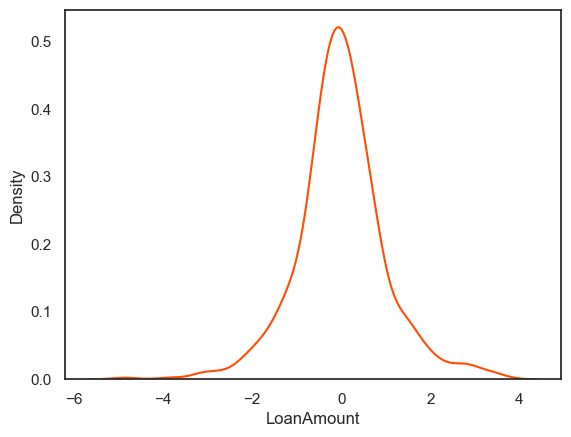

In [ ]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['LoanAmount'])
plt.show()

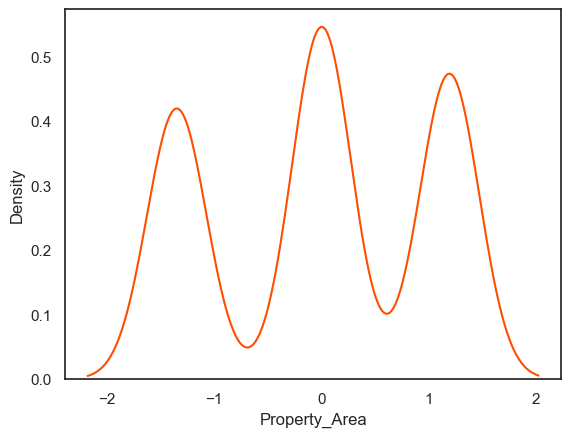

In [ ]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['Property_Area'])
plt.show()

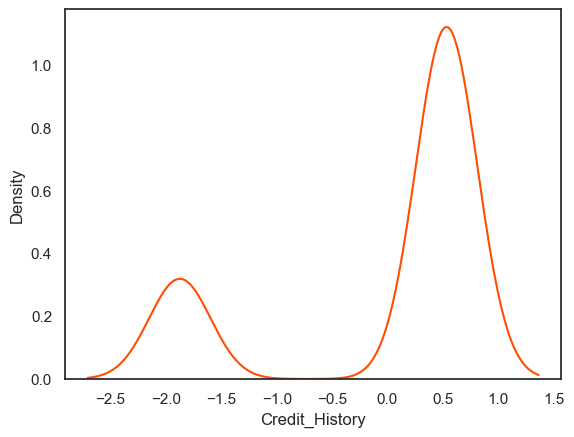

In [ ]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['Credit_History'])
plt.show()

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Gender_encoded',
       'Education_encoded', 'Property_Area_Encoded'],
      dtype='object')

In [328]:
x1=df2[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_encoded',
       'Education_encoded', 'Property_Area_Encoded']]
y1=df2['Loan_Status'].squeeze()

In [ ]:
standard=StandardScaler()
df2[['LoanAmount']]=standard.fit_transform(df2[['LoanAmount']])

In [329]:
df2.sample(10)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded
231,3716,0,42.0,180,1,1,1,0,0
470,3450,2079,162.0,360,1,1,1,1,0
228,4758,0,158.0,480,1,1,1,1,0
453,2483,2466,90.0,180,0,1,1,0,0
93,4133,0,122.0,360,1,1,1,1,0
533,11250,0,196.0,360,0,0,1,1,0
110,5316,0,136.0,360,1,1,1,2,0
498,2895,0,95.0,360,1,1,1,1,0
560,3675,242,108.0,360,1,1,1,1,1
411,6256,0,160.0,360,0,1,1,2,0


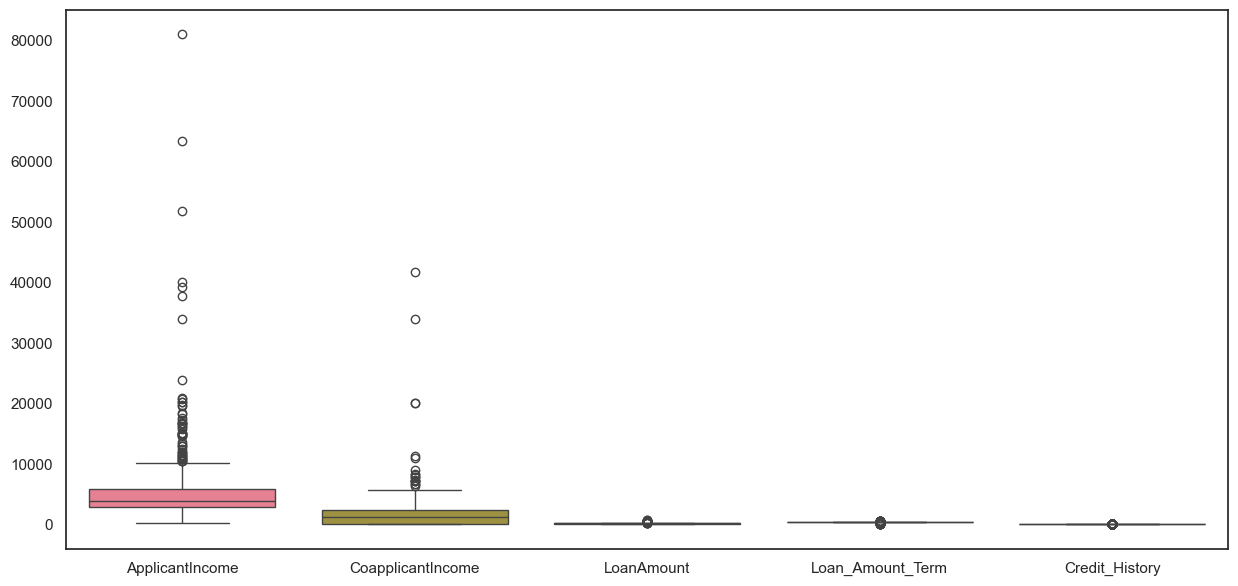

In [330]:
plt.figure(figsize=(15,7))
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.boxplot(df2[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History']])
plt.show()

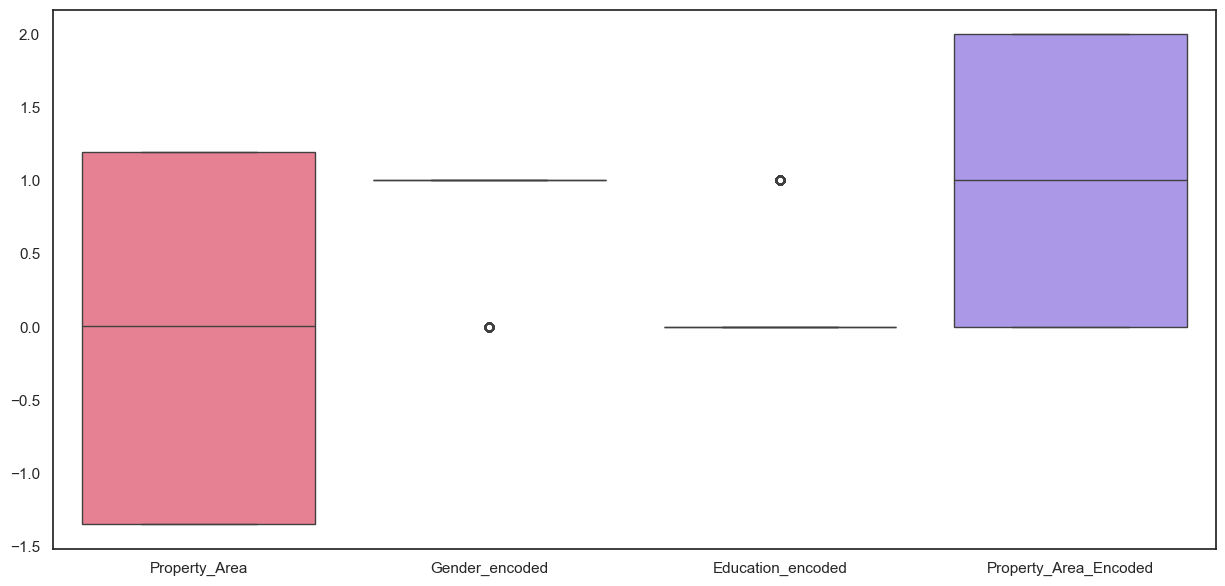

In [ ]:
plt.figure(figsize=(15,7))
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.boxplot(df2[['Property_Area', 'Gender_encoded',
       'Education_encoded', 'Property_Area_Encoded']])
plt.show()

In [336]:
df2.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_encoded',
       'Property_Area_Encoded', 'Education_encoded'],
      dtype='object')

ApplicantIncome --> [9, 34, 54, 67, 102, 106, 115, 119, 126, 128, 130, 138, 144, 146, 155, 171, 183, 185, 191, 199, 254, 258, 271, 278, 284, 308, 324, 333, 369, 370, 409, 424, 432, 438, 443, 467, 475, 478, 483, 487, 493, 506, 509, 525, 533, 534, 561, 572, 594, 604], data is --> [12841, 12500, 11500, 10750, 13650, 11417, 14583, 10408, 23803, 10513, 20166, 14999, 11757, 14866, 39999, 51763, 33846, 39147, 12000, 11000, 16250, 14683, 11146, 14583, 20667, 20233, 15000, 63337, 19730, 15759, 81000, 14880, 12876, 10416, 37719, 16692, 16525, 16667, 10833, 18333, 17263, 20833, 13262, 17500, 11250, 18165, 19484, 16666, 16120, 12000] , count is 50


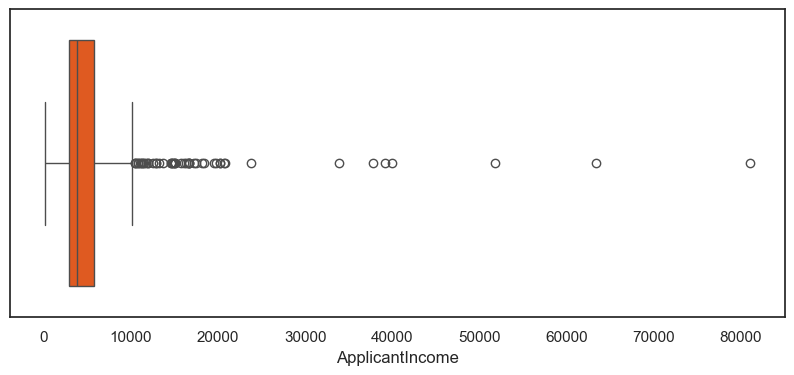

storeing the indexes
CoapplicantIncome --> [9, 12, 38, 122, 135, 177, 180, 253, 349, 372, 402, 417, 444, 506, 513, 523, 581, 600], data is --> [10968, 8106, 7210, 8980, 7750, 11300, 7250, 7101, 6250, 7873, 20000, 20000, 8333, 6667, 6666, 7166, 33837, 41667] , count is 18


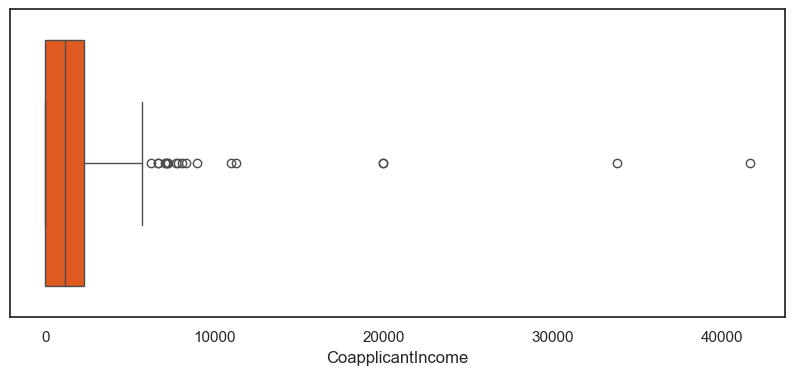

storeing the indexes
LoanAmount --> [5, 9, 21, 34, 54, 67, 83, 126, 130, 135, 155, 161, 171, 177, 233, 253, 258, 260, 278, 308, 324, 325, 333, 351, 369, 372, 381, 391, 409, 432, 487, 506, 514, 523, 525, 536, 561, 572, 592, 600, 604], data is --> [267.0, 349.0, 315.0, 320.0, 286.0, 312.0, 265.0, 370.0, 650.0, 290.0, 600.0, 275.0, 700.0, 495.0, 280.0, 279.0, 304.0, 330.0, 436.0, 480.0, 300.0, 376.0, 490.0, 308.0, 570.0, 380.0, 296.0, 275.0, 360.0, 405.0, 500.0, 480.0, 311.0, 480.0, 400.0, 324.0, 600.0, 275.0, 292.0, 350.0, 496.0] , count is 41


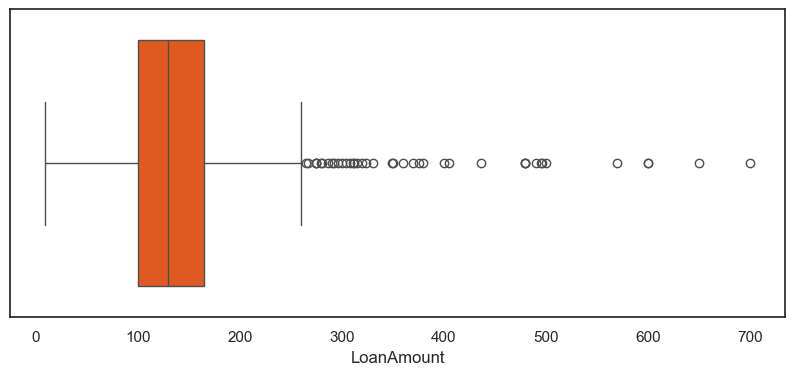

storeing the indexes
Loan_Amount_Term --> [14, 16, 36, 62, 66, 68, 72, 73, 75, 78, 84, 91, 94, 98, 100, 109, 112, 115, 128, 130, 133, 142, 144, 155, 164, 168, 171, 172, 179, 182, 186, 189, 202, 228, 231, 241, 242, 245, 247, 248, 253, 262, 282, 286, 293, 298, 313, 315, 333, 334, 355, 358, 363, 366, 367, 372, 373, 375, 378, 385, 393, 400, 401, 408, 421, 423, 429, 435, 444, 451, 453, 461, 466, 471, 476, 495, 497, 500, 504, 513, 516, 539, 540, 546, 554, 573, 575, 585, 590, 591, 593, 600, 605, 610], data is --> [120, 240, 336, 180, 180, 60, 300, 336, 480, 300, 240, 180, 120, 180, 180, 480, 336, 180, 180, 480, 120, 180, 180, 180, 180, 480, 300, 180, 480, 180, 300, 180, 180, 480, 180, 180, 60, 180, 180, 480, 180, 36, 180, 300, 480, 480, 84, 180, 180, 180, 180, 480, 300, 480, 336, 300, 180, 180, 480, 180, 180, 180, 300, 300, 336, 336, 180, 240, 300, 300, 180, 180, 180, 180, 300, 84, 12, 480, 300, 180, 480, 180, 180, 36, 180, 480, 84, 84, 180, 240, 180, 180, 180, 180] , count is 94


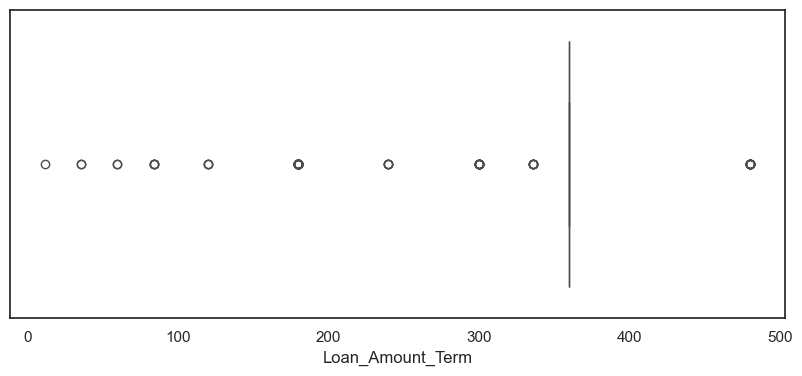

storeing the indexes
Credit_History --> [7, 17, 20, 22, 23, 24, 30, 36, 42, 48, 54, 62, 63, 64, 66, 69, 73, 78, 79, 83, 86, 95, 108, 112, 117, 122, 125, 128, 129, 130, 138, 150, 155, 156, 162, 168, 177, 179, 180, 181, 186, 187, 198, 201, 211, 218, 219, 220, 236, 237, 250, 254, 256, 259, 260, 267, 279, 280, 291, 293, 300, 307, 309, 317, 318, 323, 325, 326, 338, 346, 348, 353, 358, 363, 367, 373, 377, 387, 392, 395, 396, 399, 400, 408, 409, 411, 412, 414, 421, 423, 431, 438, 444, 448, 449, 450, 451, 452, 453, 460, 464, 466, 471, 473, 477, 486, 490, 491, 494, 499, 503, 506, 517, 527, 530, 532, 533, 541, 544, 548, 550, 553, 554, 556, 564, 565, 567, 569, 571, 576, 583, 584, 589, 597, 600, 613], data is --> [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

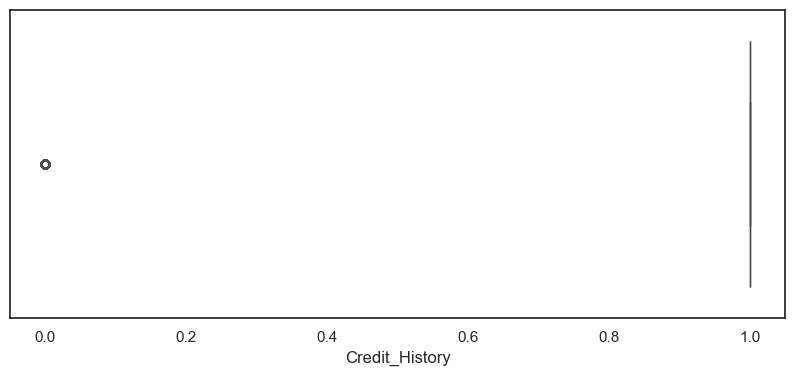

storeing the indexes
Loan_Status -> No anomolies found
Gender_encoded --> [17, 29, 37, 45, 48, 49, 50, 51, 52, 54, 64, 69, 80, 82, 96, 111, 113, 116, 119, 121, 122, 125, 136, 145, 146, 148, 166, 184, 197, 198, 205, 206, 210, 219, 233, 237, 238, 251, 255, 262, 263, 268, 269, 270, 279, 283, 286, 288, 293, 297, 298, 302, 306, 307, 310, 312, 318, 323, 328, 329, 338, 339, 341, 353, 354, 355, 360, 370, 374, 382, 396, 399, 403, 404, 405, 407, 410, 414, 415, 416, 421, 426, 430, 435, 439, 463, 468, 473, 480, 493, 495, 500, 501, 509, 516, 519, 534, 540, 541, 542, 544, 548, 556, 559, 561, 568, 582, 587, 600, 604, 609, 613], data is --> [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] , count is 112


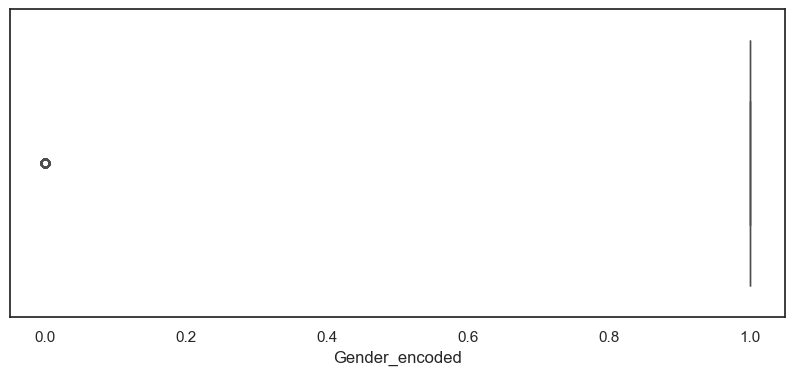

storeing the indexes
Property_Area_Encoded -> No anomolies found
Education_encoded --> [3, 6, 16, 18, 20, 22, 23, 27, 28, 39, 44, 50, 59, 62, 66, 68, 71, 73, 79, 86, 92, 94, 98, 100, 107, 109, 112, 124, 139, 153, 160, 170, 172, 174, 179, 190, 192, 197, 200, 202, 203, 204, 205, 207, 213, 215, 226, 232, 241, 244, 247, 250, 252, 253, 256, 259, 279, 280, 300, 301, 305, 309, 311, 315, 322, 338, 340, 342, 343, 346, 347, 358, 365, 386, 387, 393, 398, 400, 401, 403, 406, 407, 410, 412, 413, 414, 421, 426, 429, 439, 442, 446, 449, 450, 451, 463, 466, 468, 471, 480, 481, 485, 490, 491, 492, 493, 496, 503, 504, 510, 517, 519, 520, 527, 528, 529, 534, 535, 538, 543, 544, 546, 551, 553, 560, 563, 565, 573, 587, 595, 596, 601, 605, 607], data is --> [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

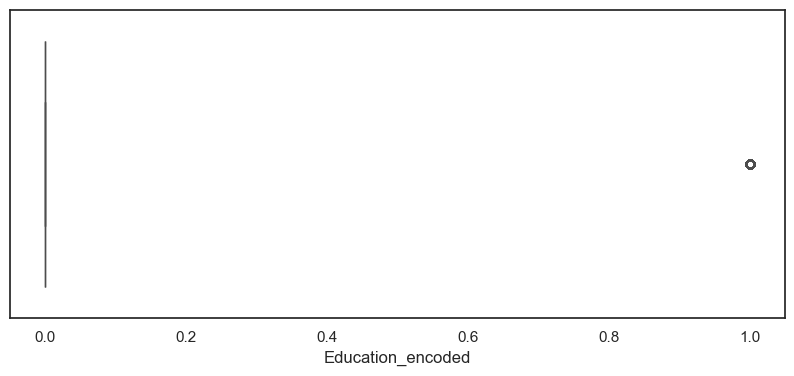

storeing the indexes
old shape is (614, 9) and new shape is (230, 9)


In [372]:
class AnomoliesClass:
    def __init__(self,data):
        self.data=data 
        
    def anomolies_detect(self,col):
        Q1=self.data[col].quantile(0.25)
        Q3=self.data[col].quantile(0.75)
        IQR=Q3-Q1
        left_bound=Q1-1.5*IQR 
        right_bound=Q3+1.5*IQR 
        mask = (self.data[col]< left_bound) | (self.data[col]> right_bound)
        anomolies_index=self.data[col][mask].index.to_list()
        anomolies_data=self.data[col][mask].to_list()
        return anomolies_index, list(anomolies_data)
    
Anomolies_instance=AnomoliesClass(df2)
numeric_col=df2.select_dtypes(include='number',exclude='object').columns
updated_index_store=set()
for each_col in numeric_col:
    anomolies_index,anomolies_data = Anomolies_instance.anomolies_detect(each_col)
    counting=len(anomolies_index)
    if anomolies_index:
        print(f"{each_col} --> {anomolies_index}, data is --> {anomolies_data} , count is {counting}")
        plt.figure(figsize=(10,4))
        sns.boxplot(data=df2,x=each_col)
        plt.savefig(f"{each_col}.png",dpi=100)
        plt.show()
        print("storeing the indexes")
        updated_index_store.update(anomolies_index)
    else:
        print(f"{each_col} -> No anomolies found")
        
df3=df2.drop(list(updated_index_store),axis=0)
print(f"old shape is {df2.shape} and new shape is {df3.shape}")

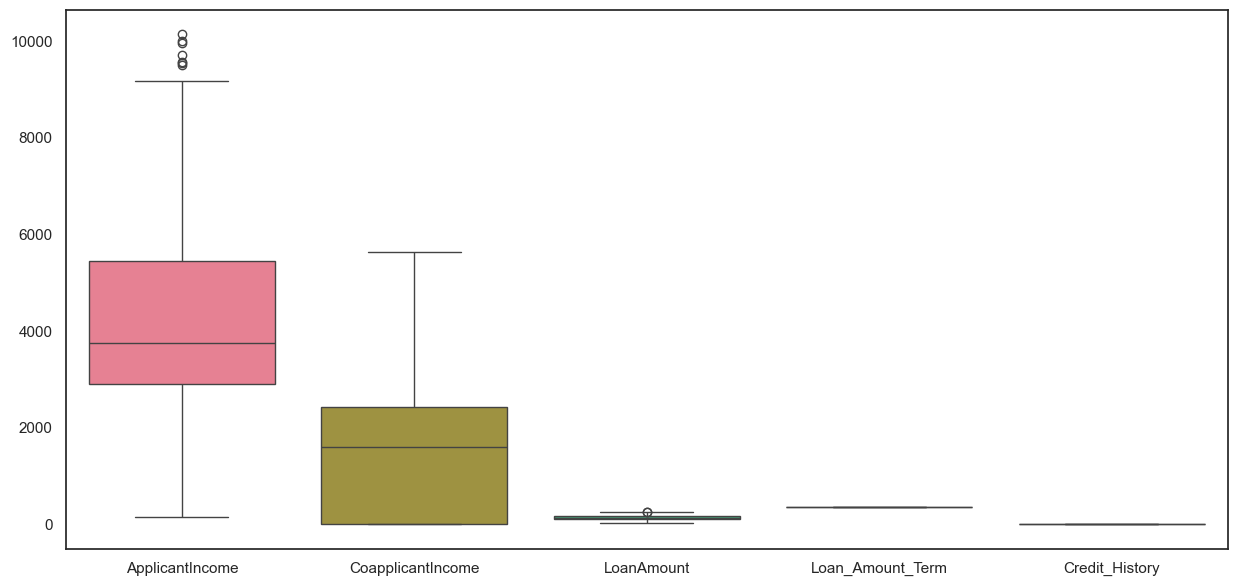

In [373]:
plt.figure(figsize=(15,7))
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.boxplot(df3[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History']])
plt.show()

In [351]:
df3.sample(10)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded
521,2500,0,55.0,360,1,1,1,1,0
257,5250,0,94.0,360,1,0,1,2,0
356,8333,3167,165.0,360,1,1,1,0,0
586,2297,1522,104.0,360,1,1,1,2,0
552,3333,3250,158.0,360,1,1,1,2,0
330,4384,1793,117.0,360,1,1,1,2,0
159,4583,5625,255.0,360,1,1,1,1,0
379,5391,0,130.0,360,1,1,1,2,0
545,2768,1950,155.0,360,1,1,1,0,0
498,2895,0,95.0,360,1,1,1,1,0


In [366]:
df3.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded
count,230.000000,230.000000,230.000000,230.0,230.0,230.000000,230.0,230.000000,230.0
mean,4288.778261,1549.486957,136.666510,360.0,1.0,0.856522,1.0,1.047826,0.0
std,2004.793502,1480.456727,45.444391,0.0,0.0,0.351324,0.0,0.777618,0.0
min,150.000000,0.000000,26.000000,360.0,1.0,0.000000,1.0,0.000000,0.0
25%,2901.250000,0.000000,107.250000,360.0,1.0,1.000000,1.0,0.000000,0.0
50%,3750.000000,1597.000000,132.000000,360.0,1.0,1.000000,1.0,1.000000,0.0
75%,5455.250000,2416.750000,167.250000,360.0,1.0,1.000000,1.0,2.000000,0.0
max,10139.000000,5625.000000,260.000000,360.0,1.0,1.000000,1.0,2.000000,0.0


In [338]:
df3.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_encoded',
       'Property_Area_Encoded', 'Education_encoded'],
      dtype='object')

In [367]:
df3.sample(10)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded
157,9538,0,187.0,360,1,1,1,2,0
43,3941,2336,134.0,360,1,1,1,1,0
4,6000,0,141.0,360,1,1,1,2,0
123,2957,0,81.0,360,1,1,1,1,0
223,7578,1010,175.0,360,1,1,1,1,0
58,8080,2250,180.0,360,1,1,1,2,0
459,8334,0,160.0,360,1,0,1,1,0
304,4000,2500,140.0,360,1,1,1,0,0
327,5818,2160,184.0,360,1,1,1,1,0
55,2708,1167,97.0,360,1,1,1,1,0


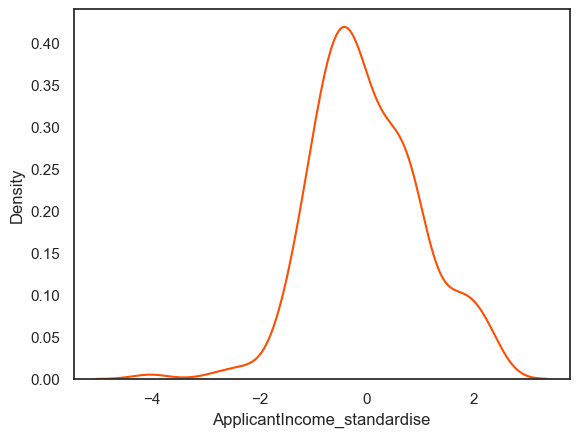

In [382]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df3['ApplicantIncome_standardise'])
plt.show()

In [379]:
df3['ApplicantIncome_standardise']=np.log(df3['ApplicantIncome'])

In [381]:
skew=PowerTransformer(method='yeo-johnson')
df3[['ApplicantIncome_standardise']]=skew.fit_transform(df3[['ApplicantIncome']])

In [ ]:
# df3[['ApplicantIncome']]=skew.inverse_transform(df3[['ApplicantIncome']])

In [383]:
df3.sample(10)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded,ApplicantIncome_standardise
362,4750,2333,130.0,360,1,1,1,2,0,0.372025
462,3015,2188,153.0,360,1,1,1,0,0,-0.572800
10,3200,700,70.0,360,1,1,1,2,0,-0.457852
221,4009,1717,116.0,360,1,1,1,1,0,0.000824
383,7167,0,128.0,360,1,1,1,2,0,1.374990
224,6250,0,128.0,360,1,1,1,1,0,1.024136
173,5708,5625,187.0,360,1,1,1,1,0,0.801238
327,5818,2160,184.0,360,1,1,1,1,0,0.847522
40,3600,0,80.0,360,1,0,1,2,0,-0.222923
368,6325,0,175.0,360,1,1,1,1,0,1.054006


In [385]:
df3.drop(columns=['ApplicantIncome_standardise'],axis=1,inplace=True)

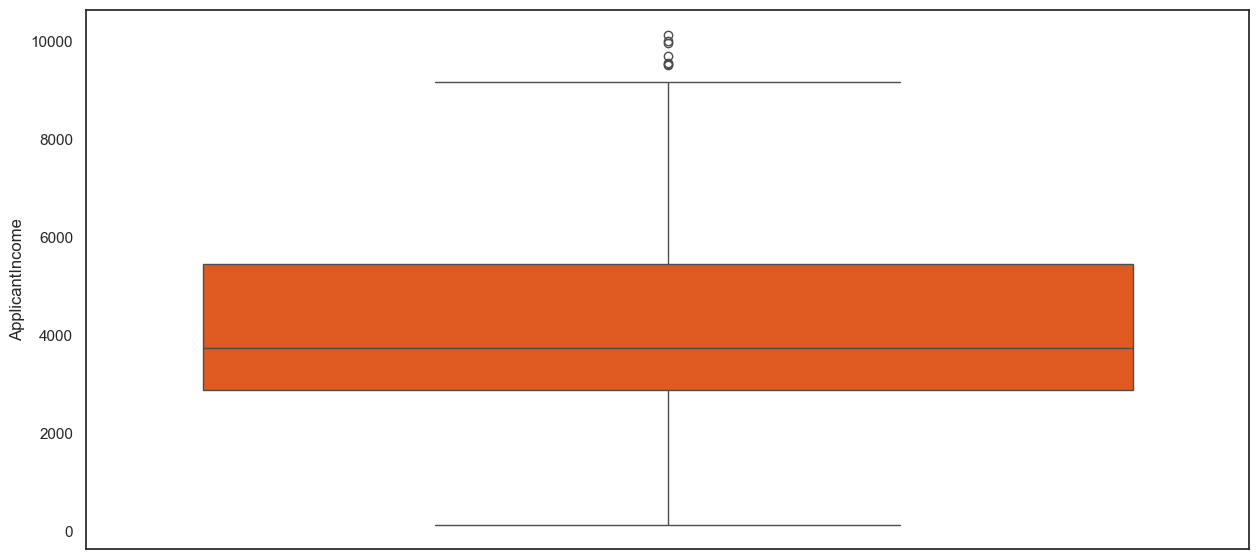

In [386]:
plt.figure(figsize=(15,7))
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.boxplot(df3['ApplicantIncome'])
plt.show()

In [387]:
df3.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_encoded',
       'Property_Area_Encoded', 'Education_encoded'],
      dtype='object')

In [388]:
x2=df3[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History','Gender_encoded',
       'Property_Area_Encoded', 'Education_encoded']]
y2=df3['Loan_Status'].squeeze()

In [445]:
df3.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_encoded,Property_Area_Encoded,Education_encoded
count,230.000000,230.000000,230.000000,230.0,230.0,230.000000,230.0,230.000000,230.0
mean,4288.778261,1549.486957,136.666510,360.0,1.0,0.856522,1.0,1.047826,0.0
std,2004.793502,1480.456727,45.444391,0.0,0.0,0.351324,0.0,0.777618,0.0
min,150.000000,0.000000,26.000000,360.0,1.0,0.000000,1.0,0.000000,0.0
25%,2901.250000,0.000000,107.250000,360.0,1.0,1.000000,1.0,0.000000,0.0
50%,3750.000000,1597.000000,132.000000,360.0,1.0,1.000000,1.0,1.000000,0.0
75%,5455.250000,2416.750000,167.250000,360.0,1.0,1.000000,1.0,2.000000,0.0
max,10139.000000,5625.000000,260.000000,360.0,1.0,1.000000,1.0,2.000000,0.0


In [389]:
x_train,x_test,y_train,y_test=train_test_split(x2,y2,test_size=0.2,random_state=42)

In [400]:
logistic=LogisticRegression(n_jobs=-1,solver='liblinear')
logistic

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [402]:
import warnings

warnings.filterwarnings('ignore')

In [403]:
cross_score=cross_val_score(logistic,x2,y2,scoring='accuracy',cv=10)
print(np.mean(cross_score))

0.8565217391304347


In [405]:
tree=DecisionTreeClassifier(splitter='best',max_depth=10,max_features='sqrt',max_leaf_nodes=10,min_samples_split=20,min_samples_leaf=5,criterion='entropy')
tree

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [409]:
#hypertunning
from sklearn.model_selection import GridSearchCV

In [414]:

params_grid={
    "criterion":['gini','entropy'],
    "max_depth":[2,4,8,10,12,15],
    "min_samples_split":[10,20,30,40,50]
}
grid=GridSearchCV(estimator=tree,param_grid=params_grid,n_jobs=-1,scoring='f1')
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ples_split=20)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [415]:
grid.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [416]:
grid.best_score_

np.float64(0.9176406967718951)

In [406]:
cross_score=cross_val_score(tree,x2,y2,scoring='accuracy',cv=10)
print(np.mean(cross_score))

0.8434782608695652


In [396]:
random=RandomForestClassifier(n_estimators=20,max_depth=20,min_samples_split=20,max_features=10,n_jobs=-1,criterion='gini')
random

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [419]:
params_grid={
    "criterion":['gini','entropy'],
    "max_depth":[2,4,8,10,12,15],
    "min_samples_split":[10,20,30,40,50]
}
grid1=GridSearchCV(estimator=random,param_grid=params_grid,n_jobs=-1,scoring='f1')
grid1.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","RandomForestC...20, n_jobs=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [420]:
grid1.best_score_

np.float64(0.9176406967718951)

In [407]:
cross_score=cross_val_score(random,x2,y2,scoring='accuracy',cv=10)
print(np.mean(cross_score))

0.8521739130434783


In [398]:
knn = KNeighborsClassifier(n_jobs=-1,n_neighbors=10, weights='distance',algorithm='auto')
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [408]:
cross_score=cross_val_score(knn,x2,y2,scoring='accuracy',cv=10)
print(np.mean(cross_score))

0.8304347826086957


In [424]:
logistic.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [425]:
tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [426]:
random.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [427]:
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [436]:
y_pred=logistic.predict(x_test)
print(y_pred)
print(logistic.score(x_test,y_test))
print(classification_report(y_test,y_pred))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1]
0.8913043478260869
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.89      1.00      0.94        41

    accuracy                           0.89        46
   macro avg       0.45      0.50      0.47        46
weighted avg       0.79      0.89      0.84        46



In [437]:
y_pred=tree.predict(x_test)
print(y_pred)
print(tree.score(x_test,y_test))
print(classification_report(y_test,y_pred))

[1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 0 1 0 1 1 1 1 1 1]
0.782608695652174
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.88      0.88      0.88        41

    accuracy                           0.78        46
   macro avg       0.44      0.44      0.44        46
weighted avg       0.78      0.78      0.78        46



In [438]:
y_pred=random.predict(x_test)
print(y_pred)
print(random.score(x_test,y_test))
print(classification_report(y_test,y_pred))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1]
0.9130434782608695
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.91      1.00      0.95        41

    accuracy                           0.91        46
   macro avg       0.96      0.60      0.64        46
weighted avg       0.92      0.91      0.89        46



In [439]:
y_pred=knn.predict(x_test)
print(y_pred)
print(knn.score(x_test,y_test))
print(classification_report(y_test,y_pred))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1]
0.8478260869565217
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.89      0.95      0.92        41

    accuracy                           0.85        46
   macro avg       0.44      0.48      0.46        46
weighted avg       0.79      0.85      0.82        46



In [440]:
import joblib

joblib.dump(logistic,"logi.joblib")

['logi.joblib']

In [444]:
df3.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_encoded',
       'Property_Area_Encoded', 'Education_encoded'],
      dtype='object')

In [ ]:
df3

In [441]:
joblib.dump(tree,"tree.joblib")

['tree.joblib']

In [442]:
joblib.dump(random,"random.joblib")

['random.joblib']

In [443]:
joblib.dump(knn,"knn.joblib")

['knn.joblib']